In [1]:
library(Seurat)
library(data.table)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.0 but the current version is
4.4.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [24]:
setwd('/gpfs/scratch/ak10083')
dir.create('scomics_assignment1_A1_P3')

ERROR: Error in setwd("/gpfs/scratch/ak10083"): cannot change working directory


In [25]:
setwd('scomics_assignment1_A1_P3/')


ERROR: Error in setwd("scomics_assignment1_A1_P3/"): cannot change working directory


In [26]:
base_dir = '/gpfs/data/courses/single_cell_omics/scrna/CR/Expression/'
files.use = list.files('/gpfs/data/courses/single_cell_omics/scrna/CR/Expression/')


In [27]:
files.use

[1] "HRR207224"                  "HRR207224_web_summary.html"
 [3] "HRR207225"                  "HRR207225_web_summary.html"
 [5] "HRR207226"                  "HRR207226_web_summary.html"
 [7] "HRR207227"                  "HRR207227_web_summary.html"
 [9] "HRR207228"                  "HRR207228_web_summary.html"
[11] "HRR207229"                  "HRR207229_web_summary.html"
[13] "HRR207230"                  "HRR207230_web_summary.html"
[15] "HRR207231"                  "HRR207231_web_summary.html"
[17] "HRR207232"                  "HRR207232_web_summary.html"
[19] "HRR207233"                  "HRR207233_web_summary.html"
[21] "HRR207234"                  "HRR207234_web_summary.html"
[23] "HRR207235"                  "HRR207235_web_summary.html"
[25] "HRR207236"                  "HRR207236_web_summary.html"
[27] "HRR207237"                  "HRR207237_web_summary.html"
[29] "HRR207238"                  "HRR207238_web_summary.html"
[31] "HRR207239"                  "HRR207239_web_summary.html"
[33] "HRR207240"                  "HRR207240_web_summary.html"
[35] "HRR207241"                  "HRR207241_web_summary.html"
[37] "HRR207242"                  "HRR207242_web_summary.html"
[39] "HRR207243"                  "HRR207243_web_summary.html"
[41] "HRR207244"                  "HRR207244_web_summary.html"
[43] "HRR207245"                  "HRR207245_web_summary.html"
[45] "HRR207246"                  "HRR207246_web_summary.html"
[47] "HRR207247"                  "HRR207247_web_summary.html"
[49] "HRR207248"                  "HRR207248_web_summary.html"
[51] "HRR207249"                  "HRR207249_web_summary.html"
[53] "HRR207250"                  "HRR207250_web_summary.html"

In [28]:
files.use = files.use[!grepl('html', files.use)]
files.use

[1] "HRR207224" "HRR207225" "HRR207226" "HRR207227" "HRR207228" "HRR207229"
 [7] "HRR207230" "HRR207231" "HRR207232" "HRR207233" "HRR207234" "HRR207235"
[13] "HRR207236" "HRR207237" "HRR207238" "HRR207239" "HRR207240" "HRR207241"
[19] "HRR207242" "HRR207243" "HRR207244" "HRR207245" "HRR207246" "HRR207247"
[25] "HRR207248" "HRR207249" "HRR207250"

In [29]:
list.files(path = paste(base_dir, files.use[1], sep ='/'))

[1] "_cmdline"          "_filelist"         "_finalstate"      
 [4] "_invocation"       "_jobmode"          "_log"             
 [7] "_mrosource"        "_perf"             "_perf._truncated_"
[10] "_sitecheck"        "_tags"             "_timestamp"       
[13] "_uuid"             "_vdrkill"          "_versions"        
[16] "extras"            "HRR207224.mri.tgz" "outs"             
[19] "SC_RNA_COUNTER_CS"

In [30]:
cellranger_paths = paste(base_dir, files.use, 'outs', sep = '/')
cellranger_paths


[1] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207224/outs"
 [2] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207225/outs"
 [3] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207226/outs"
 [4] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207227/outs"
 [5] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207228/outs"
 [6] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207229/outs"
 [7] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207230/outs"
 [8] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207231/outs"
 [9] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207232/outs"
[10] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207233/outs"
[11] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207234/outs"
[12] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207235/outs"
[13] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207236/outs"
[14] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207237/outs"
[15] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207238/outs"
[16] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207239/outs"
[17] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207240/outs"
[18] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207241/outs"
[19] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207242/outs"
[20] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207243/outs"
[21] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207244/outs"
[22] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207245/outs"
[23] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207246/outs"
[24] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207247/outs"
[25] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207248/outs"
[26] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207249/outs"
[27] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207250/outs"

In [31]:
metadata = fread('/gpfs/data/courses/single_cell_omics/hrr_minimal_metadata.tsv',data.table=F)

In [32]:
rownames(metadata) = make.unique(metadata$HRR)
sample.name = metadata[files.use,]$Title
print(sample.name)

 [1] "Expression-GC01T"       "Expression-GC02T"       "Expression-GC02T-TIL"  
 [4] "Expression-GC03P"       "Expression-GC03T-rep1"  "Expression-GC03T-rep2" 
 [7] "Expression-GC04P"       "Expression-GC04T"       "Expression-GC05P"      
[10] "Expression-GC05T"       "Expression-GC06B"       "Expression-GC06P"      
[13] "Expression-GC06T"       "Expression-GC07B"       "Expression-GC07P"      
[16] "Expression-GC07T"       "Expression-GC08B"       "Expression-GC08P"      
[19] "Expression-GC08T-site1" "Expression-GC08T-site2" "Expression-GC09P"      
[22] "Expression-GC09T"       "Expression-GC10B"       "Expression-GC10P-rep1" 
[25] "Expression-GC10P-rep2"  "Expression-GC10T"       "Expression-GC10T-TIL"  


In [33]:
sample.name = gsub('Expression-','',sample.name)
sample.name

[1] "GC01T"       "GC02T"       "GC02T-TIL"   "GC03P"       "GC03T-rep1" 
 [6] "GC03T-rep2"  "GC04P"       "GC04T"       "GC05P"       "GC05T"      
[11] "GC06B"       "GC06P"       "GC06T"       "GC07B"       "GC07P"      
[16] "GC07T"       "GC08B"       "GC08P"       "GC08T-site1" "GC08T-site2"
[21] "GC09P"       "GC09T"       "GC10B"       "GC10P-rep1"  "GC10P-rep2" 
[26] "GC10T"       "GC10T-TIL"

In [34]:
cellranger_paths[1]

[1] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207224/outs"

In [35]:
list.files(path=cellranger_paths[1])

[1] "analysis"                      "cloupe.cloupe"                
 [3] "filtered_feature_bc_matrix"    "filtered_feature_bc_matrix.h5"
 [5] "metrics_summary.csv"           "molecule_info.h5"             
 [7] "possorted_genome_bam.bam"      "possorted_genome_bam.bam.bai" 
 [9] "raw_feature_bc_matrix"         "raw_feature_bc_matrix.h5"     
[11] "web_summary.html"

In [36]:
cellranger_h5_paths = paste(cellranger_paths, 'filtered_feature_bc_matrix.h5',sep='/')
cellranger_h5_paths


[1] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207224/outs/filtered_feature_bc_matrix.h5"
 [2] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207225/outs/filtered_feature_bc_matrix.h5"
 [3] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207226/outs/filtered_feature_bc_matrix.h5"
 [4] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207227/outs/filtered_feature_bc_matrix.h5"
 [5] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207228/outs/filtered_feature_bc_matrix.h5"
 [6] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207229/outs/filtered_feature_bc_matrix.h5"
 [7] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207230/outs/filtered_feature_bc_matrix.h5"
 [8] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207231/outs/filtered_feature_bc_matrix.h5"
 [9] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207232/outs/filtered_feature_bc_matrix.h5"
[10] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207233/outs/filtered_feature_bc_matrix.h5"
[11] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207234/outs/filtered_feature_bc_matrix.h5"
[12] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207235/outs/filtered_feature_bc_matrix.h5"
[13] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207236/outs/filtered_feature_bc_matrix.h5"
[14] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207237/outs/filtered_feature_bc_matrix.h5"
[15] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207238/outs/filtered_feature_bc_matrix.h5"
[16] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207239/outs/filtered_feature_bc_matrix.h5"
[17] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207240/outs/filtered_feature_bc_matrix.h5"
[18] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207241/outs/filtered_feature_bc_matrix.h5"
[19] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207242/outs/filtered_feature_bc_matrix.h5"
[20] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207243/outs/filtered_feature_bc_matrix.h5"
[21] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207244/outs/filtered_feature_bc_matrix.h5"
[22] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207245/outs/filtered_feature_bc_matrix.h5"
[23] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207246/outs/filtered_feature_bc_matrix.h5"
[24] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207247/outs/filtered_feature_bc_matrix.h5"
[25] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207248/outs/filtered_feature_bc_matrix.h5"
[26] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207249/outs/filtered_feature_bc_matrix.h5"
[27] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207250/outs/filtered_feature_bc_matrix.h5"

In [37]:
patient.id = substr(sample.name,1,4)
patient.id

[1] "GC01" "GC02" "GC02" "GC03" "GC03" "GC03" "GC04" "GC04" "GC05" "GC05"
[11] "GC06" "GC06" "GC06" "GC07" "GC07" "GC07" "GC08" "GC08" "GC08" "GC08"
[21] "GC09" "GC09" "GC10" "GC10" "GC10" "GC10" "GC10"

In [38]:
sample.name

[1] "GC01T"       "GC02T"       "GC02T-TIL"   "GC03P"       "GC03T-rep1" 
 [6] "GC03T-rep2"  "GC04P"       "GC04T"       "GC05P"       "GC05T"      
[11] "GC06B"       "GC06P"       "GC06T"       "GC07B"       "GC07P"      
[16] "GC07T"       "GC08B"       "GC08P"       "GC08T-site1" "GC08T-site2"
[21] "GC09P"       "GC09T"       "GC10B"       "GC10P-rep1"  "GC10P-rep2" 
[26] "GC10T"       "GC10T-TIL"

In [39]:
tissue.types = c()
for(i in sample.name){
    sample.name.check = gsub('-TIL','',i)
    sample.name.check = gsub('-site1','',sample.name.check)
    sample.name.check = gsub('-site2','',sample.name.check)
    sample.name.check = gsub('-rep1','',sample.name.check)
    sample.name.check = gsub('-rep2','',sample.name.check)
    print(sample.name.check)
    if(strsplit(i,'')[[1]][nchar(sample.name.check)] == 'T'){
        tissue.types = c(tissue.types,'Tumor')
    }
    if(strsplit(i,'')[[1]][nchar(sample.name.check)] == 'B'){
        tissue.types = c(tissue.types,'Blood')
    }
    if(strsplit(i,'')[[1]][nchar(sample.name.check)] == 'P'){
        tissue.types = c(tissue.types,'Paratumor')
    }
}

[1] "GC01T"
[1] "GC02T"
[1] "GC02T"
[1] "GC03P"
[1] "GC03T"
[1] "GC03T"
[1] "GC04P"
[1] "GC04T"
[1] "GC05P"
[1] "GC05T"
[1] "GC06B"
[1] "GC06P"
[1] "GC06T"
[1] "GC07B"
[1] "GC07P"
[1] "GC07T"
[1] "GC08B"
[1] "GC08P"
[1] "GC08T"
[1] "GC08T"
[1] "GC09P"
[1] "GC09T"
[1] "GC10B"
[1] "GC10P"
[1] "GC10P"
[1] "GC10T"
[1] "GC10T"


In [40]:
tissue.types

[1] "Tumor"     "Tumor"     "Tumor"     "Paratumor" "Tumor"     "Tumor"    
 [7] "Paratumor" "Tumor"     "Paratumor" "Tumor"     "Blood"     "Paratumor"
[13] "Tumor"     "Blood"     "Paratumor" "Tumor"     "Blood"     "Paratumor"
[19] "Tumor"     "Tumor"     "Paratumor" "Tumor"     "Blood"     "Paratumor"
[25] "Paratumor" "Tumor"     "Tumor"

In [41]:
length(tissue.types)

[1] 27

In [42]:
metadata


,HRR,Title,HRS,HRX
,<chr>,<chr>,<chr>,<chr>
HRR555917,HRR555917,WES-GC10T,HRS147458,HRX402428
HRR555917.1,HRR555917,WES-GC10T,HRS147458,HRX402428
HRR555916,HRR555916,WES-GC10P,HRS147457,HRX402427
HRR555915,HRR555915,WES-GC10B,HRS147456,HRX402426
HRR555914,HRR555914,WES-GC09T,HRS147455,HRX402425
HRR555913,HRR555913,WES-GC09P,HRS147454,HRX402424
HRR555912,HRR555912,WES-GC08T-site2,HRS147453,HRX402423
HRR555911,HRR555911,WES-GC08T-site1,HRS147452,HRX402422
HRR555910,HRR555910,WES-GC08P,HRS147451,HRX402421


In [43]:
seurat_metadata = data.frame(PatientID=patient.id, Sample = sample.name, TissueType = tissue.types, row.names = rownames(metadata[files.use,]) )
seurat_metadata


,PatientID,Sample,TissueType
,<chr>,<chr>,<chr>
HRR207224,GC01,GC01T,Tumor
HRR207225,GC02,GC02T,Tumor
HRR207226,GC02,GC02T-TIL,Tumor
HRR207227,GC03,GC03P,Paratumor
HRR207228,GC03,GC03T-rep1,Tumor
HRR207229,GC03,GC03T-rep2,Tumor
HRR207230,GC04,GC04P,Paratumor
HRR207231,GC04,GC04T,Tumor
HRR207232,GC05,GC05P,Paratumor


In [44]:
cellranger_h5_paths


[1] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207224/outs/filtered_feature_bc_matrix.h5"
 [2] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207225/outs/filtered_feature_bc_matrix.h5"
 [3] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207226/outs/filtered_feature_bc_matrix.h5"
 [4] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207227/outs/filtered_feature_bc_matrix.h5"
 [5] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207228/outs/filtered_feature_bc_matrix.h5"
 [6] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207229/outs/filtered_feature_bc_matrix.h5"
 [7] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207230/outs/filtered_feature_bc_matrix.h5"
 [8] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207231/outs/filtered_feature_bc_matrix.h5"
 [9] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207232/outs/filtered_feature_bc_matrix.h5"
[10] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207233/outs/filtered_feature_bc_matrix.h5"
[11] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207234/outs/filtered_feature_bc_matrix.h5"
[12] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207235/outs/filtered_feature_bc_matrix.h5"
[13] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207236/outs/filtered_feature_bc_matrix.h5"
[14] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207237/outs/filtered_feature_bc_matrix.h5"
[15] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207238/outs/filtered_feature_bc_matrix.h5"
[16] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207239/outs/filtered_feature_bc_matrix.h5"
[17] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207240/outs/filtered_feature_bc_matrix.h5"
[18] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207241/outs/filtered_feature_bc_matrix.h5"
[19] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207242/outs/filtered_feature_bc_matrix.h5"
[20] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207243/outs/filtered_feature_bc_matrix.h5"
[21] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207244/outs/filtered_feature_bc_matrix.h5"
[22] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207245/outs/filtered_feature_bc_matrix.h5"
[23] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207246/outs/filtered_feature_bc_matrix.h5"
[24] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207247/outs/filtered_feature_bc_matrix.h5"
[25] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207248/outs/filtered_feature_bc_matrix.h5"
[26] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207249/outs/filtered_feature_bc_matrix.h5"
[27] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207250/outs/filtered_feature_bc_matrix.h5"

In [45]:
cellranger_h5_paths[c(1,4,11)]
head(seurat_metadata)

[1] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207224/outs/filtered_feature_bc_matrix.h5"
[2] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207227/outs/filtered_feature_bc_matrix.h5"
[3] "/gpfs/data/courses/single_cell_omics/scrna/CR/Expression//HRR207234/outs/filtered_feature_bc_matrix.h5"

,PatientID,Sample,TissueType
,<chr>,<chr>,<chr>
HRR207224,GC01,GC01T,Tumor
HRR207225,GC02,GC02T,Tumor
HRR207226,GC02,GC02T-TIL,Tumor
HRR207227,GC03,GC03P,Paratumor
HRR207228,GC03,GC03T-rep1,Tumor
HRR207229,GC03,GC03T-rep2,Tumor


In [46]:
# Sample subset selection for homework assignment
# Analyzing 9 samples from GC06, GC07, and GC08 patients (excluding GC08T-site2)

# Select samples:
# GC06: Blood (11), Paratumor (12), Tumor (13)
# GC07: Blood (14), Paratumor (15), Tumor (16) 
# GC08: Blood (17), Paratumor (18), Tumor-site1 (19)

# Create subset of cellranger paths
cellranger_h5_paths_use = cellranger_h5_paths[c(11, 12, 13, 14, 15, 16, 17, 18, 19)]

# Create subset of metadata
seurat_metadata_use = seurat_metadata[c(11, 12, 13, 14, 15, 16, 17, 18, 19),]

# Check the selected samples
seurat_metadata_use

,PatientID,Sample,TissueType
,<chr>,<chr>,<chr>
HRR207234,GC06,GC06B,Blood
HRR207235,GC06,GC06P,Paratumor
HRR207236,GC06,GC06T,Tumor
HRR207237,GC07,GC07B,Blood
HRR207238,GC07,GC07P,Paratumor
HRR207239,GC07,GC07T,Tumor
HRR207240,GC08,GC08B,Blood
HRR207241,GC08,GC08P,Paratumor
HRR207242,GC08,GC08T-site1,Tumor


In [2]:
library(SingleCellExperiment)
library(decontX)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [48]:

seur_objs = list()
for(i in seq(1,nrow(seurat_metadata_use))){
    print(i)
    print(rownames(seurat_metadata_use)[i])
    seur_obj = CreateSeuratObject(Read10X_h5(cellranger_h5_paths_use[i]))
    seur_obj@meta.data$PatientID = seurat_metadata_use[i,1]
    seur_obj@meta.data$Sample = seurat_metadata_use[i,2]
    seur_obj@meta.data$TissueType = seurat_metadata_use[i,3]
    seur_obj = RenameCells(seur_obj, new.names = paste(rownames(seurat_metadata_use)[i],
                                                       colnames(seur_obj), sep = "_")
                           )
    seur_objs[[rownames(seurat_metadata_use)[i]]] = seur_obj

    filter_matrix = Read10X_h5(cellranger_h5_paths_use[i])
    raw_matrix = Read10X_h5(gsub('filtered','raw',cellranger_h5_paths_use[i]))
    sce_filter_matrix =  SingleCellExperiment(list(counts = filter_matrix))
    sce_raw_matrix =  SingleCellExperiment(list(counts = raw_matrix))
    sce <- decontX(sce_filter_matrix, background = sce_raw_matrix)
    seur_objs[[rownames(seurat_metadata_use)[i]]]@meta.data$DecontX_contamination = sce$decontX_contamination
}

seur_obj = Reduce(merge, seur_objs)

saveRDS(
  seur_obj,
  file = "/gpfs/scratch/ajn8926/spring_semester/scOmics/seur_obj_merged.rds"
)

saveRDS(
  seur_objs,
  file = "/gpfs/scratch/ajn8926/spring_semester/scOmics/seur_objs_list.rds"
)

[1] 1
[1] "HRR207234"


Tue Feb 10 11:23:54 2026 ..  1440  cells in the background matrix were removed as they were found in  the filtered matrix.

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Tue Feb 10 11:23:54 2026 .. Analyzing all cells

Tue Feb 10 11:23:54 2026 .... Generating UMAP and estimating cell types

Tue Feb 10 11:24:04 2026 .... Estimating contamination

Tue Feb 10 11:24:04 2026 ...... Completed iteration: 10 | converge: 0.03177

Tue Feb 10 11:24:05 2026 ...... Completed iteration: 20 | converge: 0.01263

Tue Feb 10 11:24:06 2026 ...... Completed iteration: 30 | converge: 0.006976

Tue Feb 10 11:24:07 2026 ...... Completed iteration: 40 | converge: 0.0048

Tue Feb 10 11:24:08 2026 ...... Completed iteration: 50 | converge: 0.003992

Tue Feb 10 11:24:08 2026 ...... Completed iteration: 60 | converge: 0.003143

Tue Feb 10 11:24:09 2026 ...... Completed iteration: 70 | converge: 0.002305

Tue Feb 10 11:24:10 2026 ...... Co

[1] 2
[1] "HRR207235"


Tue Feb 10 11:24:29 2026 ..  11458  cells in the background matrix were removed as they were found in  the filtered matrix.

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Tue Feb 10 11:24:29 2026 .. Analyzing all cells

Tue Feb 10 11:24:29 2026 .... Generating UMAP and estimating cell types

Tue Feb 10 11:25:05 2026 .... Estimating contamination

Tue Feb 10 11:25:13 2026 ...... Completed iteration: 10 | converge: 0.1299

Tue Feb 10 11:25:19 2026 ...... Completed iteration: 20 | converge: 0.01558

Tue Feb 10 11:25:25 2026 ...... Completed iteration: 30 | converge: 0.004485

Tue Feb 10 11:25:32 2026 ...... Completed iteration: 40 | converge: 0.002892

Tue Feb 10 11:25:38 2026 ...... Completed iteration: 50 | converge: 0.001262

Tue Feb 10 11:25:41 2026 ...... Completed iteration: 54 | converge: 0.0009824

Tue Feb 10 11:25:41 2026 .. Calculating final decontaminated matrix

----------------------------------------

[1] 3
[1] "HRR207236"


...

Tue Feb 10 11:32:50 2026 ..  7966  cells in the background matrix were removed as they were found in  the filtered matrix.

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Tue Feb 10 11:32:50 2026 .. Analyzing all cells

Tue Feb 10 11:32:50 2026 .... Generating UMAP and estimating cell types

Tue Feb 10 11:33:30 2026 .... Estimating contamination

Tue Feb 10 11:33:35 2026 ...... Completed iteration: 10 | converge: 0.03998

Tue Feb 10 11:33:40 2026 ...... Completed iteration: 20 | converge: 0.01628

Tue Feb 10 11:33:44 2026 ...... Completed iteration: 30 | converge: 0.009769

Tue Feb 10 11:33:49 2026 ...... Completed iteration: 40 | converge: 0.006921

Tue Feb 10 11:33:53 2026 ...... Completed iteration: 50 | converge: 0.005788

Tue Feb 10 11:33:57 2026 ...... Completed iteration: 60 | converge: 0.004529

Tue Feb 10 11:34:02 2026 ...... Completed iteration: 70 | converge: 0.003503

Tue Feb 10 11:34:06 2026 ...... 

[1] 8
[1] "HRR207241"


Tue Feb 10 11:34:41 2026 ..  7678  cells in the background matrix were removed as they were found in  the filtered matrix.

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Tue Feb 10 11:34:42 2026 .. Analyzing all cells

Tue Feb 10 11:34:42 2026 .... Generating UMAP and estimating cell types

Tue Feb 10 11:35:14 2026 .... Estimating contamination

Tue Feb 10 11:35:20 2026 ...... Completed iteration: 10 | converge: 0.01861

Tue Feb 10 11:35:25 2026 ...... Completed iteration: 20 | converge: 0.004557

Tue Feb 10 11:35:30 2026 ...... Completed iteration: 30 | converge: 0.003144

Tue Feb 10 11:35:35 2026 ...... Completed iteration: 40 | converge: 0.002196

Tue Feb 10 11:35:40 2026 ...... Completed iteration: 50 | converge: 0.00161

Tue Feb 10 11:35:45 2026 ...... Completed iteration: 60 | converge: 0.001247

Tue Feb 10 11:35:50 2026 ...... Completed iteration: 70 | converge: 0.0009708

Tue Feb 10 11:35:50 2026 .. Cal

[1] 9
[1] "HRR207242"


Tue Feb 10 11:36:10 2026 ..  9323  cells in the background matrix were removed as they were found in  the filtered matrix.

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Tue Feb 10 11:36:10 2026 .. Analyzing all cells

Tue Feb 10 11:36:10 2026 .... Generating UMAP and estimating cell types

Tue Feb 10 11:36:48 2026 .... Estimating contamination

Tue Feb 10 11:36:56 2026 ...... Completed iteration: 10 | converge: 0.06683

Tue Feb 10 11:37:03 2026 ...... Completed iteration: 20 | converge: 0.044

Tue Feb 10 11:37:10 2026 ...... Completed iteration: 30 | converge: 0.01986

Tue Feb 10 11:37:17 2026 ...... Completed iteration: 40 | converge: 0.006813

Tue Feb 10 11:37:24 2026 ...... Completed iteration: 50 | converge: 0.00364

Tue Feb 10 11:37:30 2026 ...... Completed iteration: 60 | converge: 0.005349

Tue Feb 10 11:37:37 2026 ...... Completed iteration: 70 | converge: 0.01465

Tue Feb 10 11:37:44 2026 ...... Compl

In [13]:
head(seur_objs[[1]]@meta.data)
seur_obj = Reduce(merge, seur_objs)

ERROR: Error in seur_objs[[1]]@meta.data: no applicable method for `@` applied to an object of class "data.frame"


In [3]:
# # # ## # ## ## # ## ##

seur_obj  <- readRDS("/gpfs/scratch/ajn8926/spring_semester/scOmics/seur_obj_merged.rds")
seur_objs <- readRDS("/gpfs/scratch/ajn8926/spring_semester/scOmics/seur_objs_list.rds")


In [4]:
seur_obj = JoinLayers(seur_obj)

In [9]:
seur_obj

An object of class Seurat 
38606 features across 74813 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [10]:
table(seur_obj@meta.data$Sample)


      GC06B       GC06P       GC06T       GC07B       GC07P       GC07T 
       1440       11458       18108        8584        2950        7306 
      GC08B       GC08P GC08T-site1 
       7966        7678        9323 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


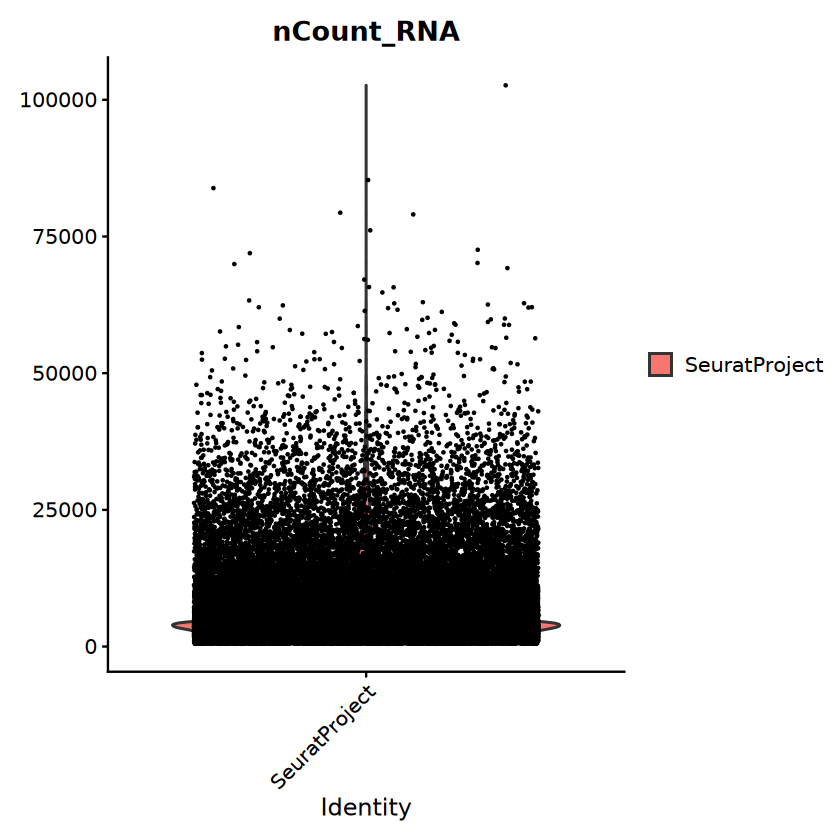

In [11]:
VlnPlot(seur_obj, 'nCount_RNA')

In [12]:
head(seur_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,PatientID,Sample,TissueType,DecontX_contamination
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>
HRR207234_AAACCTGTCACTTATC-1,SeuratProject,4278,2043,GC06,GC06B,Blood,0.01179787
HRR207234_AAACGGGAGCGCCTCA-1,SeuratProject,974,700,GC06,GC06B,Blood,0.96890053
HRR207234_AAACGGGGTCATCCCT-1,SeuratProject,3319,1504,GC06,GC06B,Blood,0.02388756
HRR207234_AAACGGGGTTCGTTGA-1,SeuratProject,3168,1548,GC06,GC06B,Blood,0.01436345
HRR207234_AAAGATGTCTGGGCCA-1,SeuratProject,8194,2430,GC06,GC06B,Blood,0.01190649
HRR207234_AAAGCAAAGCGTTTAC-1,SeuratProject,3027,1457,GC06,GC06B,Blood,0.04206891


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


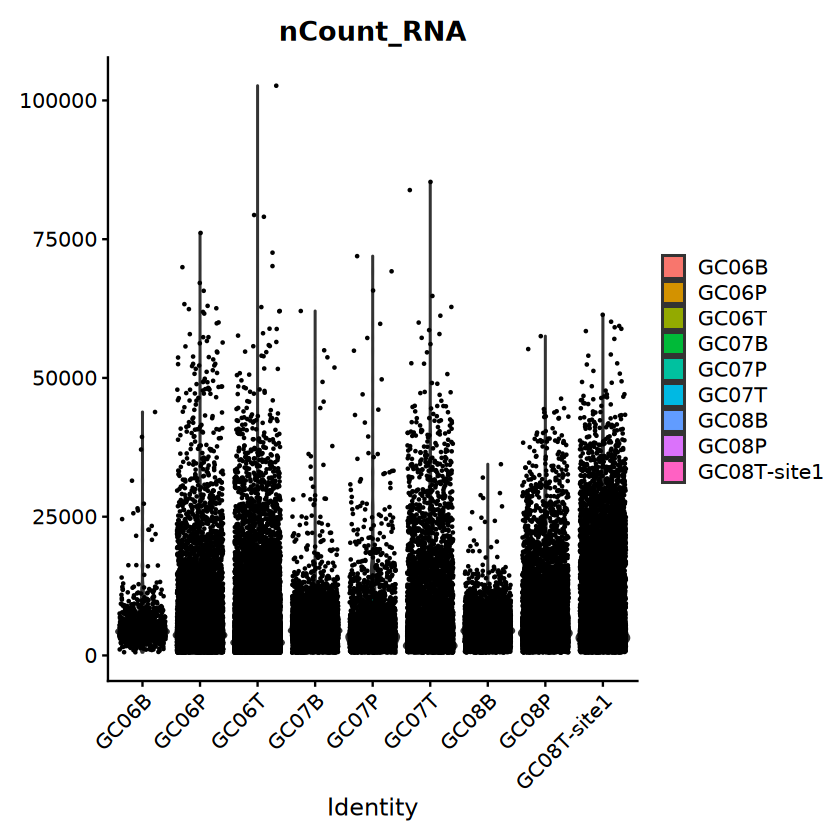

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


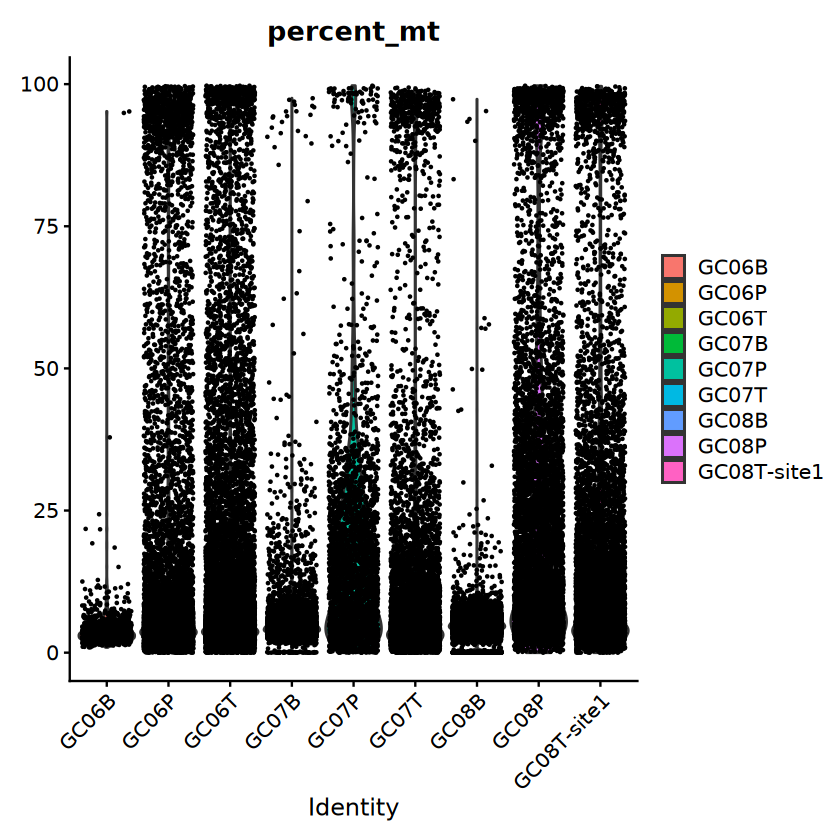

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


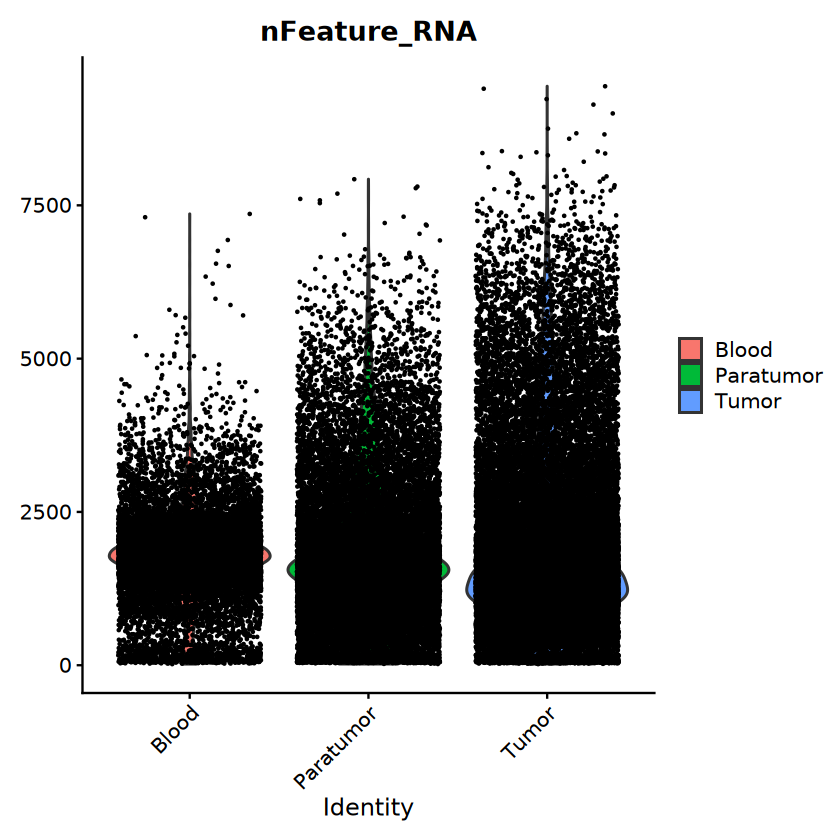

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


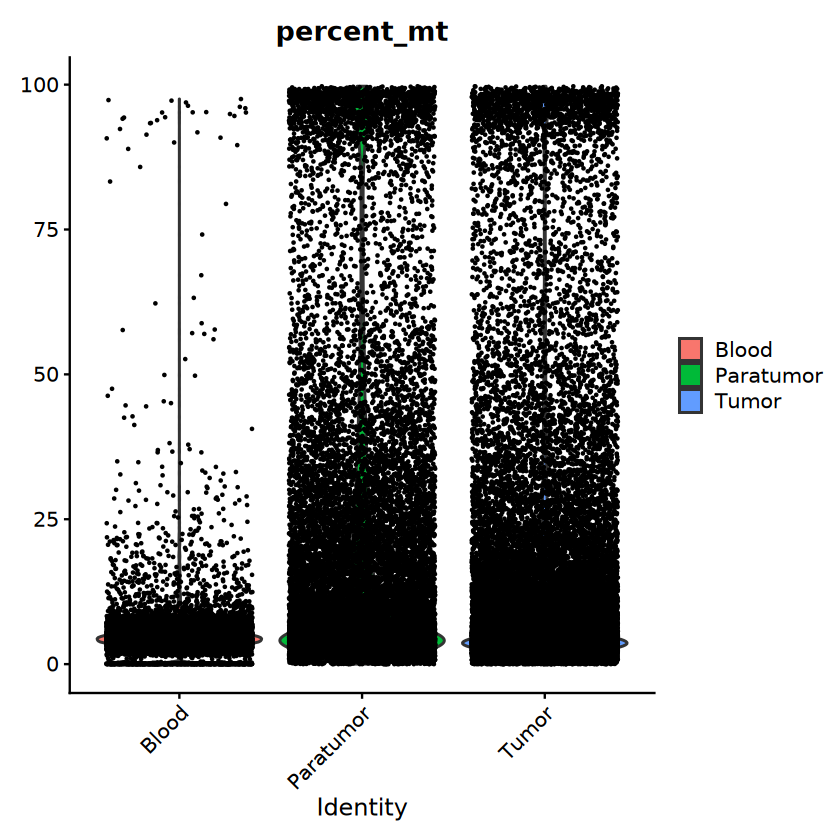

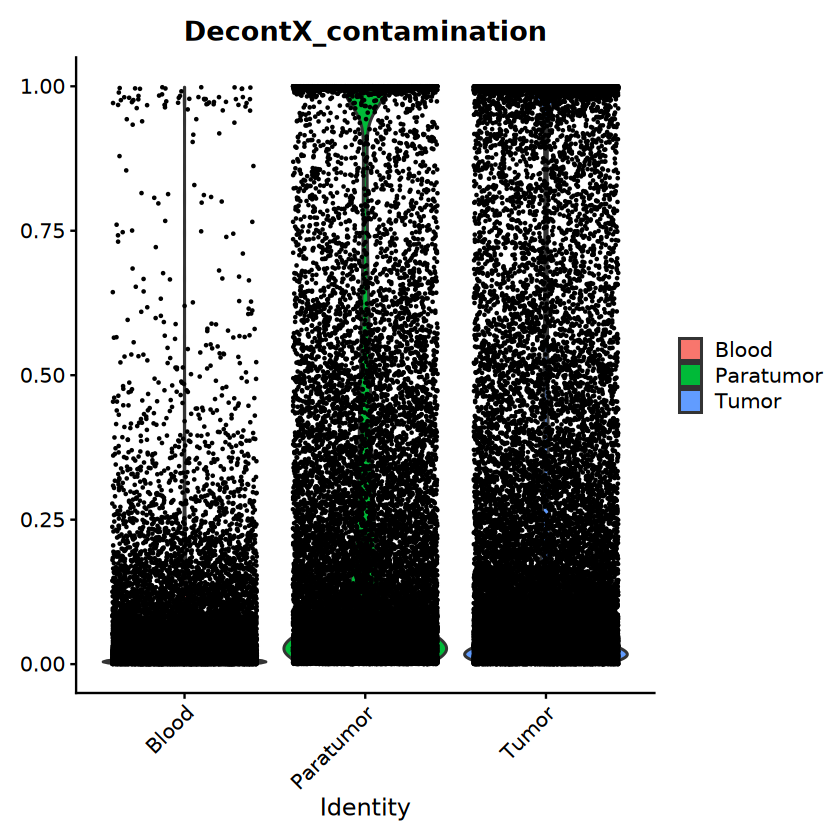

In [13]:
VlnPlot(seur_obj, 'nCount_RNA',group.by = 'Sample')
seur_obj@meta.data$percent_mt = PercentageFeatureSet(seur_obj, pattern = "MT-")
VlnPlot(seur_obj, 'percent_mt',group.by = 'Sample')
VlnPlot(seur_obj, 'nFeature_RNA',group.by = 'TissueType')
VlnPlot(seur_obj, 'percent_mt',group.by = 'TissueType')
VlnPlot(seur_obj, 'DecontX_contamination',group.by = 'TissueType')

In [14]:
# Load required library
library(ggplot2)

# Now create the plots with titles
p1 <- VlnPlot(seur_obj, 'nCount_RNA', group.by = 'TissueType') + 
      ggtitle("UMI Counts per Cell")
p2 <- VlnPlot(seur_obj, 'nFeature_RNA', group.by = 'TissueType') + 
      ggtitle("Genes Detected per Cell")
p3 <- VlnPlot(seur_obj, 'percent_mt', group.by = 'TissueType') + 
      ggtitle("Mitochondrial Percentage")
p4 <- VlnPlot(seur_obj, 'DecontX_contamination', group.by = 'TissueType') + 
      ggtitle("Ambient RNA Contamination")

# Combine and save
library(patchwork)
combined <- (p1 | p2) / (p3 | p4)
ggsave("QC_violin_plots.png", plot = combined, width = 14, height = 10, dpi = 300)


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


In [15]:
# Load required library
library(ggplot2)

# Now create the plots with titles
p1 <- VlnPlot(seur_obj, 'nCount_RNA', group.by = 'Sample') + 
      ggtitle("UMI Counts per Cell")
p2 <- VlnPlot(seur_obj, 'nFeature_RNA', group.by = 'Sample') + 
      ggtitle("Genes Detected per Cell")
p3 <- VlnPlot(seur_obj, 'percent_mt', group.by = 'Sample') + 
      ggtitle("Mitochondrial Percentage")
p4 <- VlnPlot(seur_obj, 'DecontX_contamination', group.by = 'Sample') + 
      ggtitle("Ambient RNA Contamination")

# Combine and save
library(patchwork)
combined <- (p1 | p2) / (p3 | p4)
ggsave("QC_violin_plots_bysample.png", plot = combined, width = 14, height = 10, dpi = 300)


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


In [5]:
# Summary of UMIs per sample
tapply(seur_obj@meta.data$nCount_RNA, seur_obj@meta.data$Sample, summary)


$GC06B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    571    3697    4590    5194    5759   43861 

$GC06P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    502    2457    3826    5830    5838   76125 

$GC06T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    2087    3236    5442    5966  102652 

$GC07B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    3768    4680    5096    5760   62059 

$GC07P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    2294    3892    5349    6239   71944 

$GC07T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    503    2007    3713    6434    6615   85319 

$GC08B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    501    3888    4832    5134    6082   34450 

$GC08P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    505    3456    5004    7201    8698   57527 

$`GC08T-site1`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    500    3016    4874    9336   13770   61383 


In [6]:

# Summary of genes per sample
tapply(seur_obj@meta.data$nFeature_RNA, seur_obj@meta.data$Sample, summary)


$GC06B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     43    1469    1707    1791    1971    6511 

$GC06P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     20    1046    1539    1654    2044    7780 

$GC06T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     23     951    1346    1624    2002    9442 

$GC07B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     26    1501    1744    1787    2004    7360 

$GC07P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     36    1008    1593    1709    2245    7023 

$GC07T
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   26.0   983.2  1615.0  1902.2  2361.8  9402.0 

$GC08B
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     18    1549    1854    1764    2115    5875 

$GC08P
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     33    1088    1696    1965    2649    7926 

$`GC08T-site1`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     19    1303    1827    2464    3561    9233 


In [7]:

# Summary of % mitochondrial per sample
tapply(seur_obj@meta.data$percent_mt, seur_obj@meta.data$Sample, summary)

ERROR: Error in tapply(seur_obj@meta.data$percent_mt, seur_obj@meta.data$Sample, : arguments must have same length


In [8]:
#filtering based on the paper -> remove cells with <400 UMI, <200 genes or >30% MT DNA

seur_obj = seur_obj[, seur_obj@meta.data$nCount_RNA > 400 & 
                       seur_obj@meta.data$nFeature_RNA > 200 & 
                       seur_obj@meta.data$percent_mt < 30]

ERROR: Error in `[.Seurat`(seur_obj, , seur_obj@meta.data$nCount_RNA > 400 & : Incorrect number of logical values provided to subset cells


In [9]:
seur_obj

An object of class Seurat 
38606 features across 74813 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [10]:
#keep genes expressed in 10 or more cells 

gene_boolean = rowSums(LayerData(seur_obj,layer='counts') > 0) >  10
seur_obj

An object of class Seurat 
38606 features across 74813 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [11]:
seur_obj = seur_obj[gene_boolean,]
seur_obj

An object of class Seurat 
29318 features across 74813 samples within 1 assay 
Active assay: RNA (29318 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


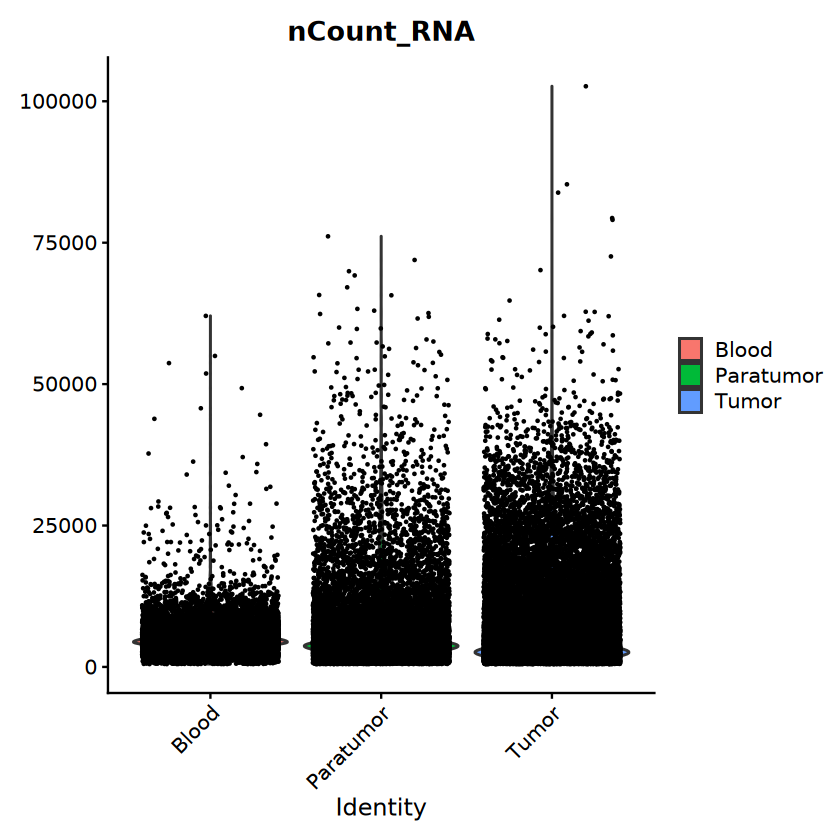

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


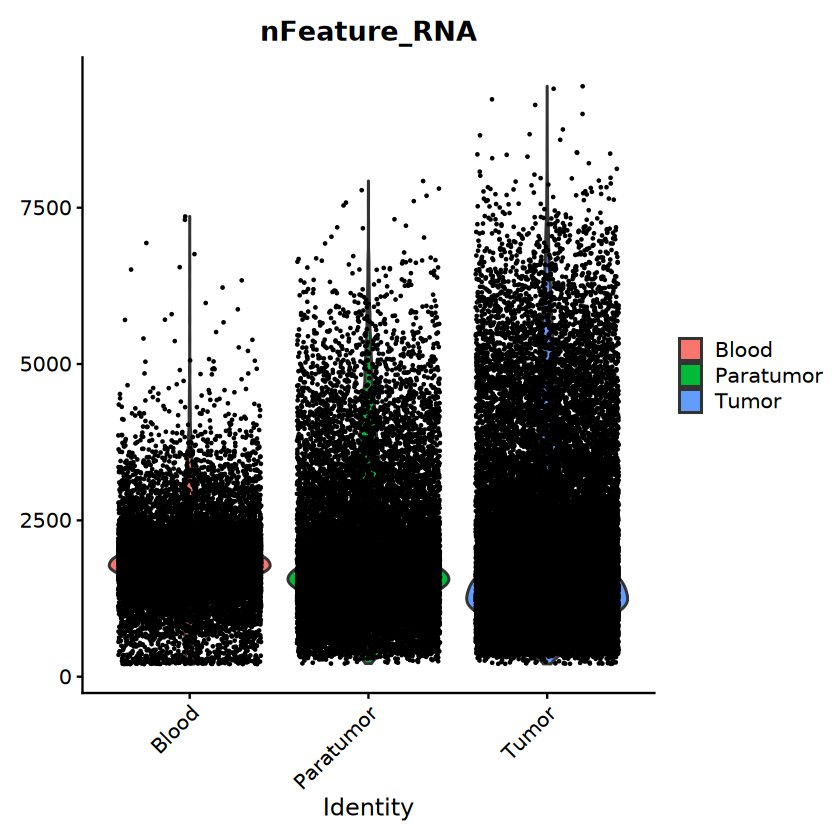

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


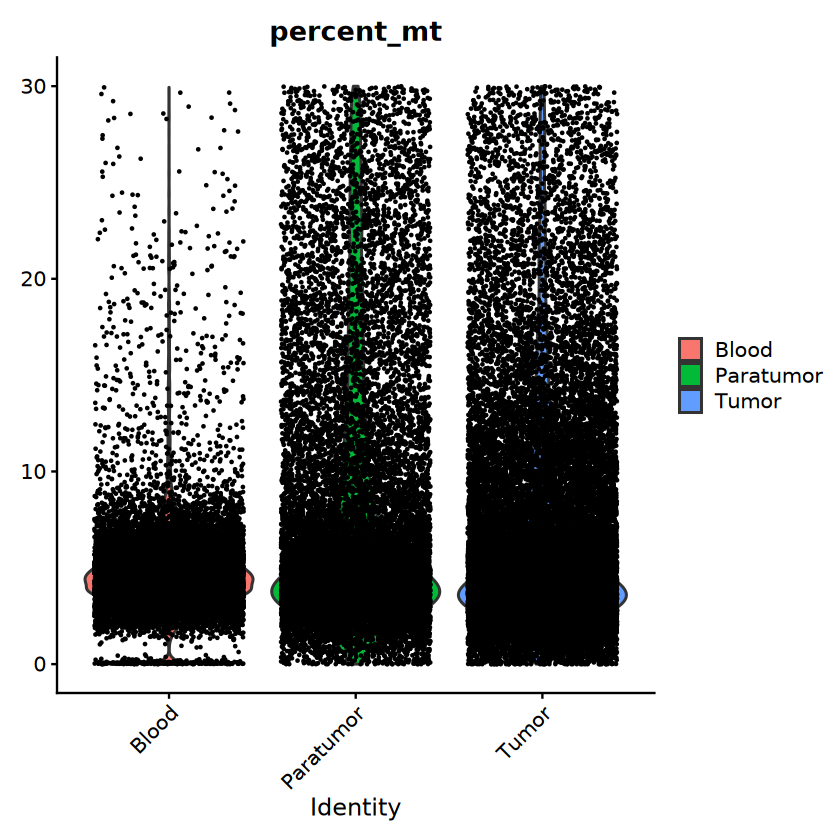

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


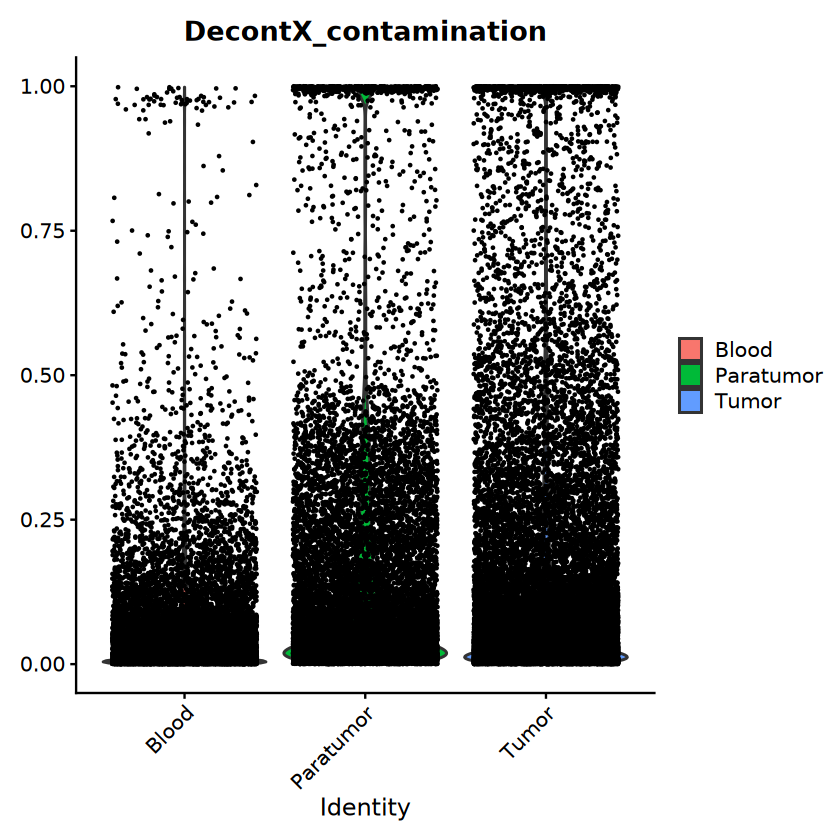

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


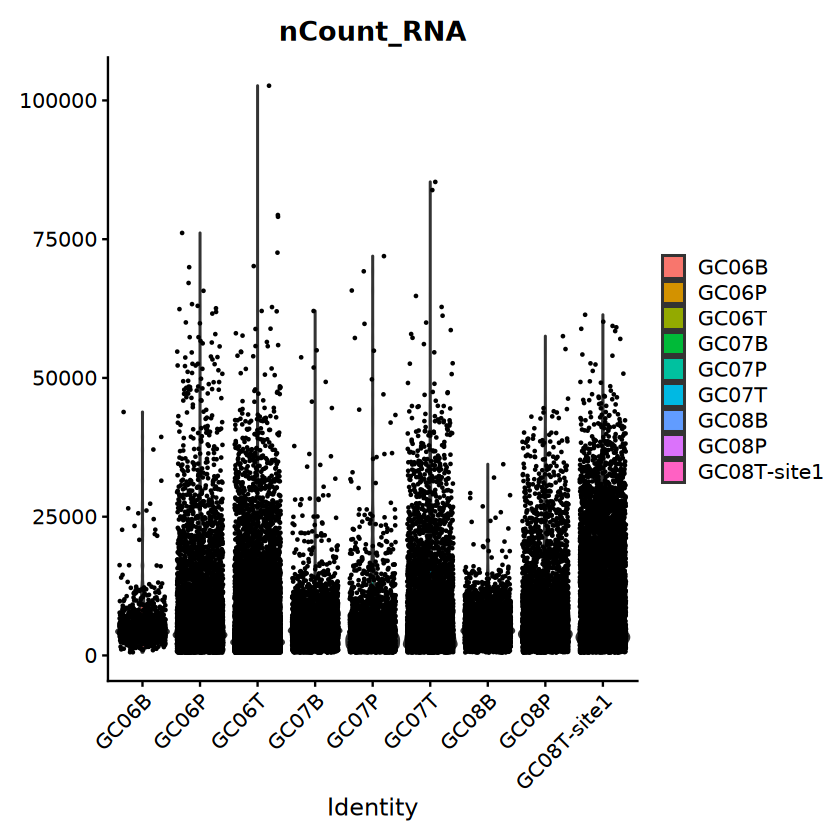

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


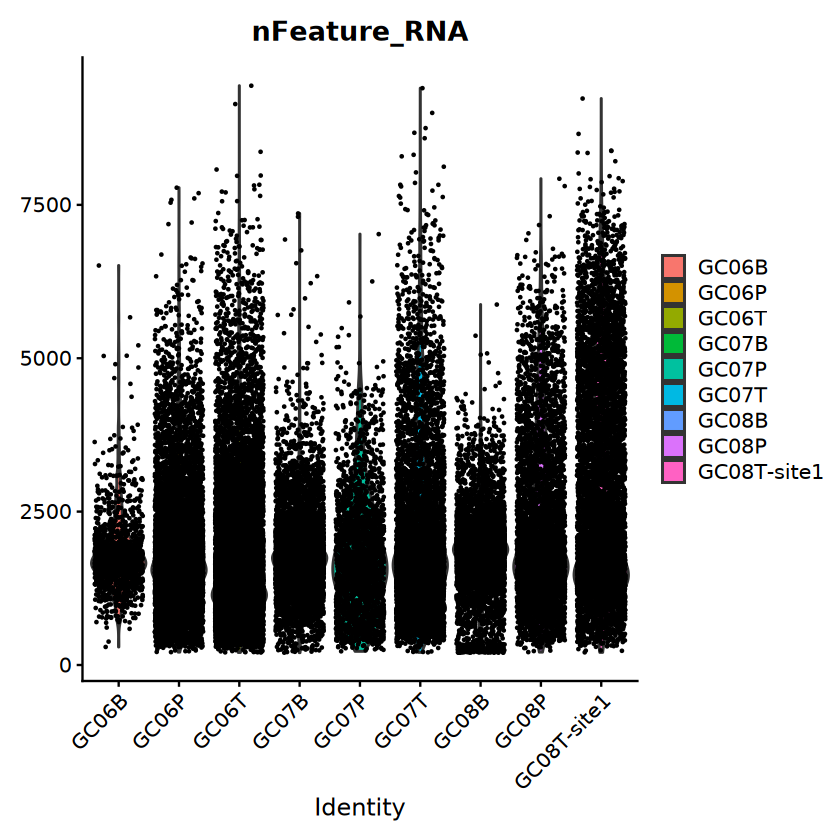

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


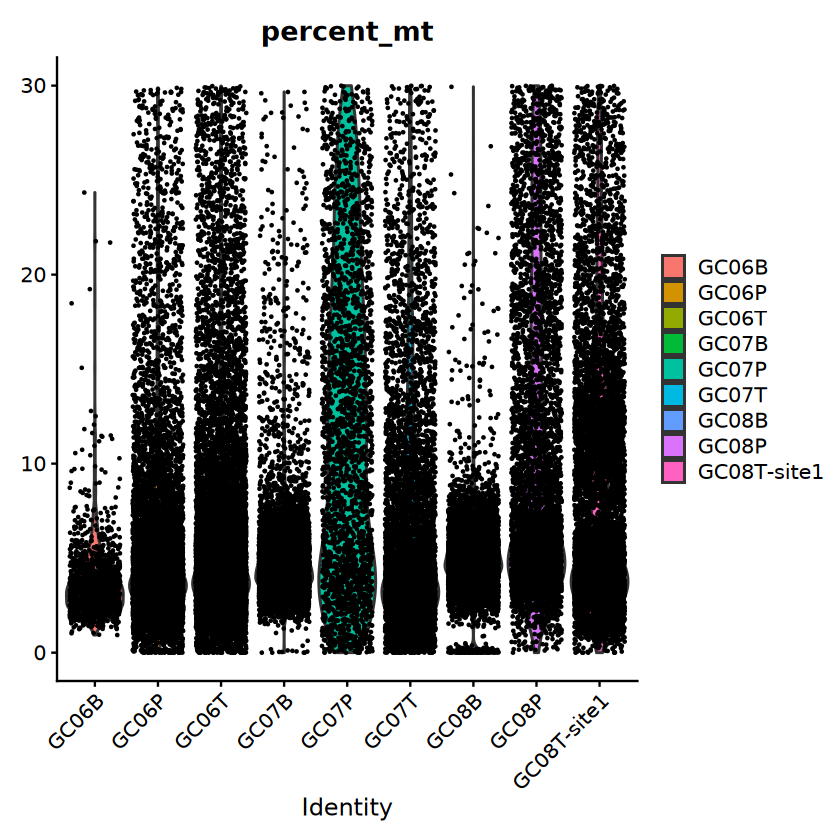

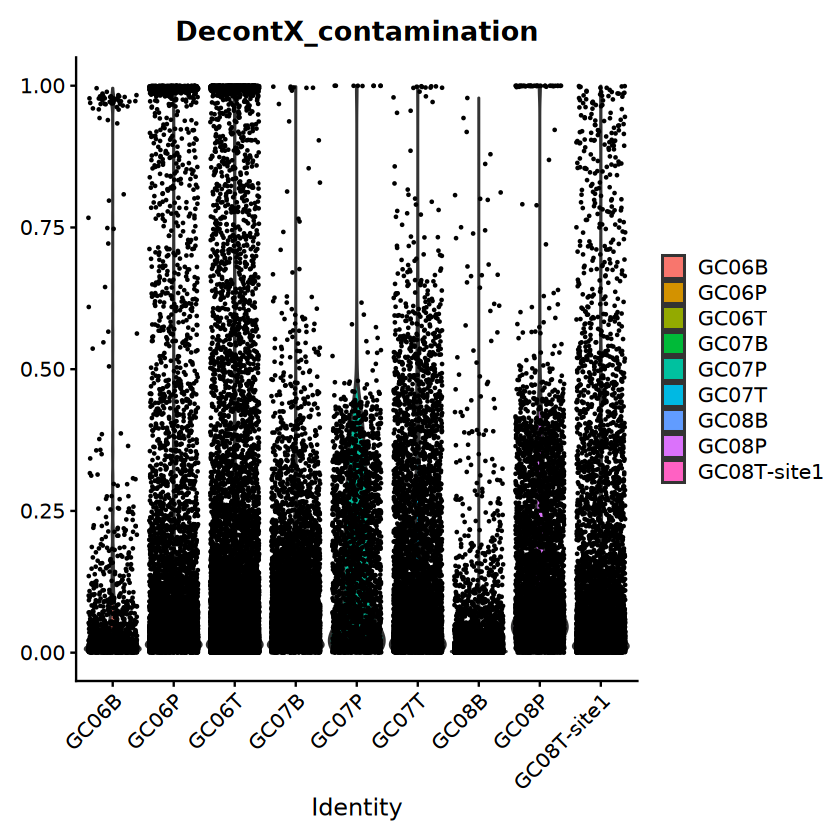

In [23]:
#redo QC figures after filtering and removing 

# Violin plots grouped by Tissue Type
VlnPlot(seur_obj, 'nCount_RNA', group.by = 'TissueType')
ggsave("nCount_RNA_by_tissue_post_filter.png", width = 8, height = 6)

VlnPlot(seur_obj, 'nFeature_RNA', group.by = 'TissueType')
ggsave("nFeature_RNA_by_tissue_post_filter.png", width = 8, height = 6)

VlnPlot(seur_obj, 'percent_mt', group.by = 'TissueType')
ggsave("percent_mt_by_tissue_post_filter.png", width = 8, height = 6)

VlnPlot(seur_obj, 'DecontX_contamination', group.by = 'TissueType')
ggsave("DecontX_by_tissue_post_filter.png", width = 8, height = 6)

# Violin plots grouped by Sample
VlnPlot(seur_obj, 'nCount_RNA', group.by = 'Sample')
ggsave("nCount_RNA_by_sample_post_filter.png", width = 10, height = 6)

VlnPlot(seur_obj, 'nFeature_RNA', group.by = 'Sample')
ggsave("nFeature_RNA_by_sample_post_filter.png", width = 10, height = 6)

VlnPlot(seur_obj, 'percent_mt', group.by = 'Sample')
ggsave("percent_mt_by_sample_post_filter.png", width = 10, height = 6)

VlnPlot(seur_obj, 'DecontX_contamination', group.by = 'Sample')
ggsave("DecontX_by_sample_post_filter.png", width = 10, height = 6)

In [24]:
head(seur_obj@meta.data)


,orig.ident,nCount_RNA,nFeature_RNA,PatientID,Sample,TissueType,DecontX_contamination,percent_mt
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
HRR207234_AAACCTGTCACTTATC-1,SeuratProject,4278,2043,GC06,GC06B,Blood,0.01179787,3.179056
HRR207234_AAACGGGAGCGCCTCA-1,SeuratProject,974,700,GC06,GC06B,Blood,0.96890053,9.856263
HRR207234_AAACGGGGTCATCCCT-1,SeuratProject,3319,1504,GC06,GC06B,Blood,0.02388756,2.922567
HRR207234_AAACGGGGTTCGTTGA-1,SeuratProject,3168,1548,GC06,GC06B,Blood,0.01436345,4.135101
HRR207234_AAAGATGTCTGGGCCA-1,SeuratProject,8194,2430,GC06,GC06B,Blood,0.01190649,3.746644
HRR207234_AAAGCAAAGCGTTTAC-1,SeuratProject,3027,1457,GC06,GC06B,Blood,0.04206891,4.856293


In [12]:
seur_obj[["RNA"]] <- split(seur_obj[["RNA"]], f = seur_obj$Sample)
seur_obj = JoinLayers(seur_obj)

In [ ]:
seur_obj = NormalizeData(seur_obj) # every cell's counts gets divided by the total number of counts in that cell and then multiplied by 10k and then logged

Normalizing layer: counts



In [ ]:
seur_obj = FindVariableFeatures(seur_obj)
seur_obj = ScaleData(seur_obj)
seur_obj = RunPCA(seur_obj)

#based on this I conclude the following 


In [ ]:
seur_obj = FindNeighbors(seur_obj)

In [ ]:
seur_obj = FindClusters(seur_obj, algorithm=4,resolution=1,leiden_method='igraph')
head(seur_obj@meta.data)

In [ ]:
table(seur_obj@meta.data$seurat_clusters)

In [ ]:
seur_obj = FindClusters(seur_obj, algorithm=4,resolution=0.1,leiden_method='igraph')

In [ ]:
table(seur_obj@meta.data$seurat_clusters)

In [ ]:
ElbowPlot(seur_obj)

In [ ]:
seur_obj = RunUMAP(seur_obj,dims=1:15,verbose=F)

In [ ]:
head(seur_obj@meta.data)

In [ ]:
DimPlot(seur_obj, group.by = 'Sample')

In [ ]:
DimPlot(seur_obj, group.by = 'seurat_clusters')

In [ ]:
DimPlot(seur_obj, group.by = 'TissueType')

In [ ]:
library(harmony)


In [ ]:
library(presto)

In [ ]:
marker.df = FindAllMarkers(seur_obj,group.by = 'seurat_clusters',logfc.threshold = 1)

In [ ]:
marker.df.cluster = split(marker.df, marker.df$cluster)

In [ ]:
lapply(marker.df.cluster, head,10)

In [ ]:
# Create annotation mapping
cluster_annotations <- c(
  "0" = "Other",  # If you have cluster 0
  "1" = "T cells",
  "2" = "Normal Epithelial",
  "3" = "B cells",
  "4" = "Tumor Epithelial",
  "5" = "Plasma cells",
  "6" = "Macrophages",
  "7" = "Fibroblasts",
  "8" = "Endothelial",
  "9" = "Mast cells",
  "10" = "Enteroendocrine",
  "11" = "Proliferating",
  "12" = "Erythrocytes"
)

# Add cell type annotation to metadata
seur_obj$celltype <- cluster_annotations[as.character(seur_obj$seurat_clusters)]

# View distribution
table(seur_obj$celltype, seur_obj$TissueType)

In [ ]:
tissue_distribution = prop.table(table(seur_obj@meta.data$seurat_clusters, seur_obj@meta.data$TissueType),margin=1)
pheatmap(tissue_distribution,cluster_rows=F,cluster_cols=F)


In [ ]:
saveRDS(
  seur_obj,
  file = "/gpfs/scratch/ajn8926/spring_semester/scOmics/seur_obj_merged_final.rds"
)
print('saved')
